# SolidGen content characterization
This file analyzes data extracted from `https://git.autodesk.com/lambouj/proc_step/blob/master/proc_step/solidgen_with_spline_stats.py` to produce statistics on the number of B-Rep models which can be consumed by SolidGen with additional spline support.

As always, content characterization is a "map-reduce" workflow.   The script `solidgen_with_spline_stats.py` maps B-Rep bodies to json data.   This notebook is the "reduce" step, which aggregates stats from all the json files.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm import tqdm
from IPython.display import display, Markdown
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images
import random
import math

In [2]:
# Path to the json file
data_path = Path("../processed_data/cluster_info.json")

In [19]:
with open(data_path, 'r') as fp:
    cluster_image_name_dict = json.load(fp)

In [8]:
print(cluster_image_name_dict.keys())

dict_keys(['23', '2', '20', '10', '6', '8', '5', '7', '12', '16', '0', '1', '22', '11', '17', '4', '24', '14', '15', '21', '9', '3', '13', '18', '19'])


In [9]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
#     png_paths = []
#     json_paths = []
    num_images_per_row = 5
    k = num_images_per_row*num_images_per_row
#     for s in file_stems:
#         chunk = s[0:4]
#         chunk_path = image_path / chunk
#         png_path = chunk_path / (s + ".png")
#         if png_path.exists():
#             png_paths.append(png_path)
#             json_path =  chunk_path / (s.rpartition("_")[0] + ".json")
#             assert json_path.exists(), "Json files doesn't exist"
#             json_paths.append(json_path)

            
    total_num_images = len(png_paths)
#     if total_num_images == 0:
#         print("No bodies found")
#         return None
    
    if k > total_num_images:
        k = total_num_images
    chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in chosen_indices:
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
#         with open(json_file, "r") as fp:
#             data = json.load(fp)
#         texts.append(data["solid_name"])
        
    num_images = len(imgs)
    sq_max = math.ceil(math.sqrt(num_images))
    grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    return grid

In [31]:
def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'../raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

## Gallery

In [ ]:
def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")

Part images in cluster No.24 from view 00

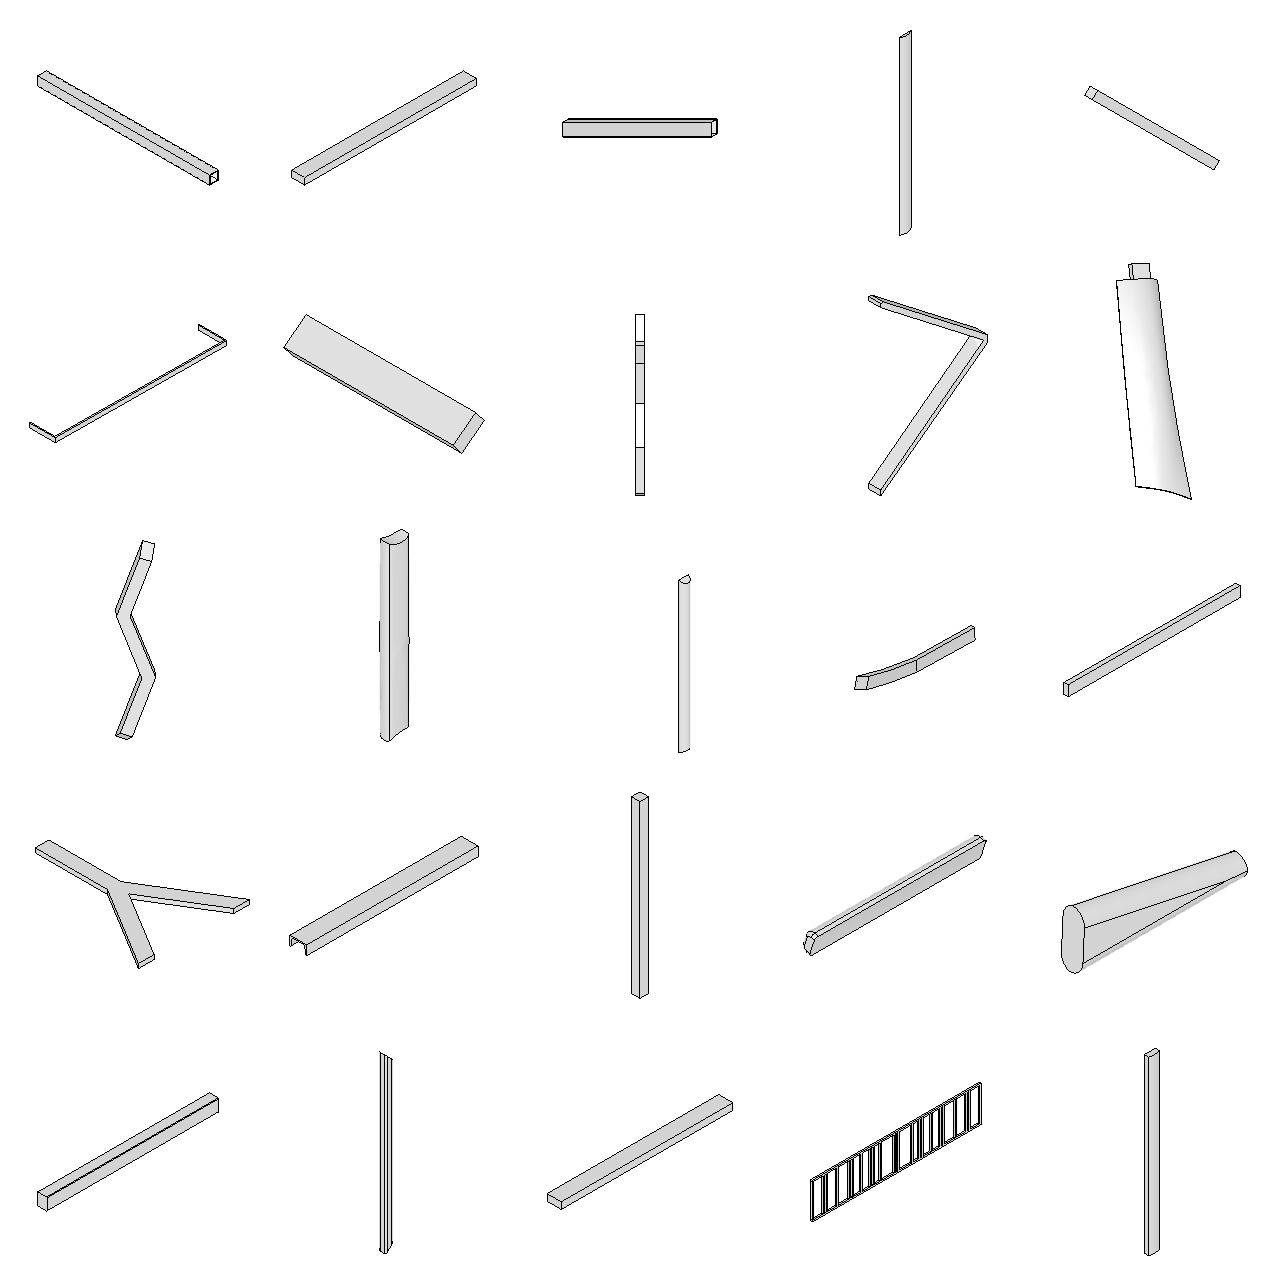

In [95]:
cluster_no = '24'

part_image_assigned_to_cluster = cluster_image_name_dict[cluster_no].copy()

vid = '00'

part_image_assigned_to_cluster = extend_metadata_to_filepath(part_image_assigned_to_cluster, vid)

display_image_grid(f"Part images in cluster No.{cluster_no} from view {vid}", part_image_assigned_to_cluster)